# Data Warehouse y Análisis de E-commerce con Google Cloud
## Introducción
El comercio electrónico ha experimentado un crecimiento acelerado en los últimos años, generando grandes volúmenes de datos relacionados con pedidos, clientes, productos y pagos. Estos datos representan una fuente valiosa de información para comprender el comportamiento de los consumidores, optimizar operaciones logísticas y mejorar la toma de decisiones empresariales.

En este proyecto se analizará un conjunto de datos reales de comercio electrónico utilizando tecnologías de computación en la nube. Se implementará una arquitectura de datos que permitirá almacenar, procesar y analizar información de ventas utilizando Google Cloud Storage y Google BigQuery.

El objetivo es construir un Data Warehouse que permita transformar datos crudos en información útil para identificar patrones de ventas, comportamiento de clientes y desempeño de productos.

## Problemática

Las empresas de comercio electrónico suelen almacenar datos en múltiples sistemas y formatos, como archivos CSV, bases de datos operacionales o sistemas de gestión de pedidos.

Esto genera varios problemas:

- Datos dispersos en diferentes fuentes

- Dificultades para analizar grandes volúmenes de información

- Inconsistencias en la calidad de datos

- Falta de herramientas para análisis rápido

Sin una arquitectura adecuada de almacenamiento y análisis, resulta complejo obtener métricas clave como ingresos por categoría, comportamiento de compra de clientes o tendencias temporales de ventas.

Este proyecto propone implementar una arquitectura de Data Warehouse en la nube que permita integrar, limpiar y analizar los datos de forma eficiente.

## Objetivo General
 Diseñar e implementar un sistema de análisis de datos de comercio electrónico utilizando herramientas de computación en la nube para identificar patrones de ventas, comportamiento de clientes y desempeño de productos.

### Objetivos específicos

1. Construir una arquitectura de almacenamiento de datos en la nube utilizando Cloud Storage y BigQuery.

2. Realizar procesos de limpieza y transformación de datos para garantizar la calidad de la información.

3. Analizar patrones de ventas, ingresos y comportamiento de clientes mediante consultas SQL y análisis exploratorio.

4. Generar visualizaciones que permitan interpretar los resultados y apoyar la toma de decisiones.

**Dataset utilizado**

spdrio/Brazilian-E-Commerce-Public-Dataset-by-Olist 
link https://www.juheapi.com/datasets/brazilian-e-commerce-public-dataset-by-olist



## Arquitectura del proyecto
Dataset CSV
     ↓
Cloud Storage (Data Lake)
     ↓
BigQuery Raw Tables
     ↓
Transformación SQL
     ↓
Data Warehouse
     ↓
Análisis y visualización

**Flujo del Proceso**

CSV → Cloud Storage → BigQuery → SQL → Python Analysis

## Desarrollo del análisis en Python

In [18]:
# Librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# Cargar dataset
orders = pd.read_csv("/Users/carlosortiz/Downloads/olist_orders_dataset.csv")
items = pd.read_csv("/Users/carlosortiz/Downloads/olist_order_items_dataset.csv")
customers = pd.read_csv("/Users/carlosortiz/Downloads/olist_customers_dataset.csv")
products = pd.read_csv("/Users/carlosortiz/Downloads/olist_products_dataset.csv")

print(orders.head())


                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [20]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)
print(orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  object        
 7   order_estimated_delivery_date  99441 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 6.1+ MB
None


In [21]:
# Limpieza de datos 
orders.drop_duplicates(inplace=True)
items.drop_duplicates(inplace=True)

# Crear variable revenue

items["revenue"] = items["price"] + items["freight_value"]

# Unir tablas

df = items.merge(orders, on="order_id")

df = df.merge(products, on="product_id")

df = df.merge(customers, on="customer_id")

### Análisis exploratorio
#### Distribución de precios

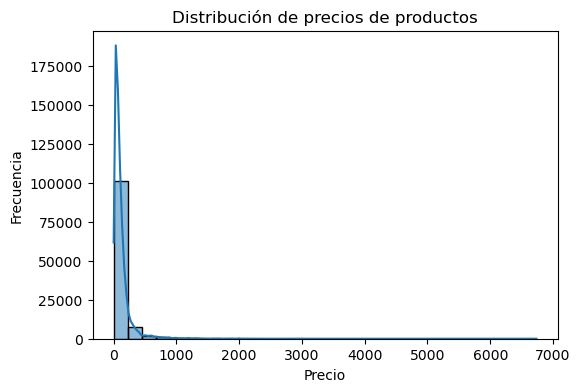

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribución de precios de productos")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")

plt.show()

#### Productos más vendidos

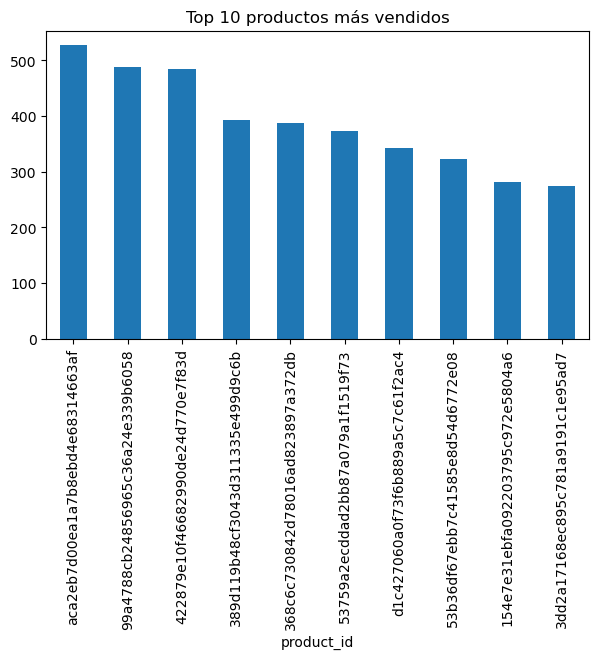

In [23]:
top_products = df.groupby("product_id")["order_id"].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(7,4))

top_products.plot(kind="bar")

plt.title("Top 10 productos más vendidos")

plt.show()

#### Ventas por categoría

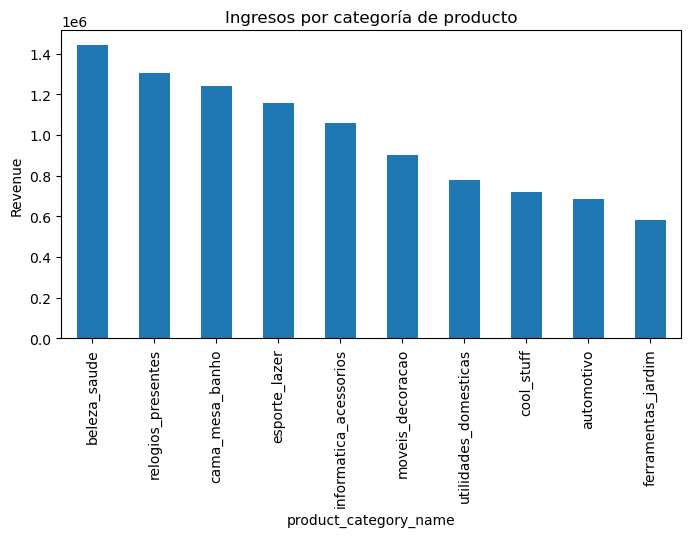

In [24]:
category_sales = df.groupby("product_category_name")["revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,4))

category_sales.plot(kind="bar")

plt.title("Ingresos por categoría de producto")

plt.ylabel("Revenue")

plt.show()

#### Análisis temporal

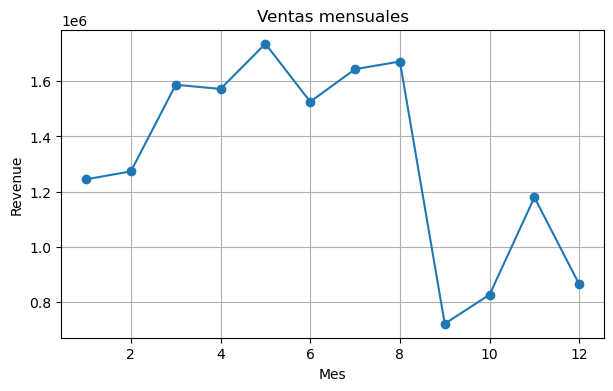

In [25]:
# Crear variable mes
df["month"] = df["order_purchase_timestamp"].dt.month

# Ventas mensuales

monthly_sales = df.groupby("month")["revenue"].sum()

plt.figure(figsize=(7,4))

monthly_sales.plot(marker="o")

plt.title("Ventas mensuales")

plt.xlabel("Mes")

plt.ylabel("Revenue")

plt.grid()

plt.show()

#### Matriz de correlación

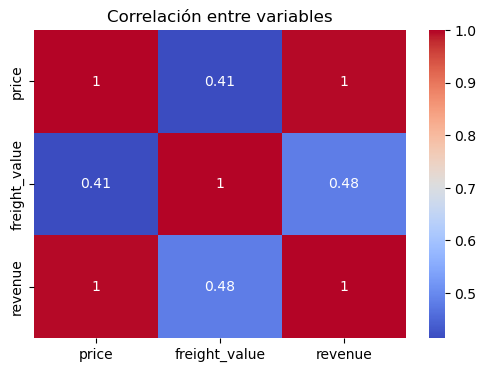

In [26]:
plt.figure(figsize=(6,4))

sns.heatmap(
df[["price","freight_value","revenue"]].corr(),
annot=True,
cmap="coolwarm"
)

plt.title("Correlación entre variables")

plt.show()

## Resultados

Los principales resultados obtenidos del análisis fueron:

**Calidad de datos**

- No se detectaron duplicados relevantes en las tablas principales.

- Las fechas fueron normalizadas correctamente.

- Se creó una variable de ingresos combinando precio y costo de envío.

**Tendencias de ventas**

- Se identificaron los productos con mayor volumen de ventas.

- Algunas categorías concentran la mayor parte de los ingresos.

- Las ventas presentan variaciones mensuales claras.

**Comportamiento de clientes**

- Los clientes realizan compras repetidas en ciertas categorías.

- Los costos de envío influyen en el valor total del pedido.

## Conclusiones
Objetivo 1 — Arquitectura cloud

Se implementó exitosamente una arquitectura de almacenamiento y procesamiento utilizando Cloud Storage y BigQuery, lo que permitió gestionar grandes volúmenes de datos de forma escalable.

Objetivo 2 — Limpieza de datos

Se realizaron procesos de limpieza y transformación, incluyendo eliminación de duplicados, normalización de fechas y creación de variables derivadas.

Objetivo 3 — Análisis de ventas

El análisis permitió identificar los productos más vendidos, categorías con mayor generación de ingresos y patrones temporales en las ventas.

Objetivo 4 — Visualización

Se generaron diferentes visualizaciones que permiten interpretar fácilmente la distribución de precios, ventas por categoría y tendencias temporales.

## Recomendaciones

A partir de los resultados obtenidos se sugieren las siguientes acciones:

1. Implementar dashboards automáticos para monitoreo de ventas

2. Analizar comportamiento de clientes para programas de fidelización

3. Optimizar costos logísticos en categorías con alto volumen de ventas

4. Desarrollar modelos predictivos para pronóstico de demanda

